# 03 — EDA: four questions, four figures
Every figure answers a question that justifies a downstream design choice.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.loaders import load, SENSORS_ALL, SENSORS, RegimeAssigner, Normalizer, HEALTHY_RUL
from sklearn.decomposition import PCA

tr1, tr3, tr4 = load('FD001'), load('FD003'), load('FD004')

## Q1 — Which sensors are informative?

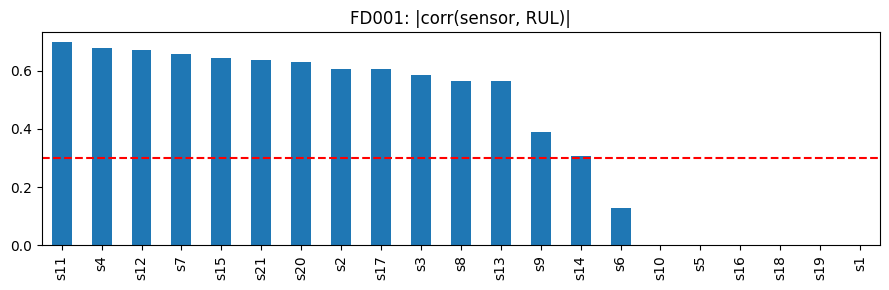

top sensor: s11 0.7 | constant: ['s1', 's5', 's10', 's16', 's18', 's19'] | kept 14: ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


In [2]:
corr1 = {s: abs(np.corrcoef(tr1[s], tr1.rul)[0, 1]) if tr1[s].std() > 1e-9 else 0.0
         for s in SENSORS_ALL}
corr1 = pd.Series(corr1).sort_values(ascending=False)
ax = corr1.plot.bar(figsize=(9, 3), title='FD001: |corr(sensor, RUL)|')
ax.axhline(0.3, ls='--', c='r'); plt.tight_layout()
plt.savefig('../results/figures/03_q1_corr.png', dpi=120); plt.show()
const = [s for s in SENSORS_ALL if tr1[s].std() < 1e-6]
print('top sensor:', corr1.index[0], round(corr1.iloc[0], 2),
      '| constant:', const, '| kept 14:', SENSORS)

s11 leads (0.70); s1,s5,s10,s16,s18,s19 are exactly constant (zero information ⇒ dropped at
zero loss). The 14-sensor list in `src.loaders.SENSORS` is fixed here for all notebooks.

## Q2 — Is healthy vs degraded separable?

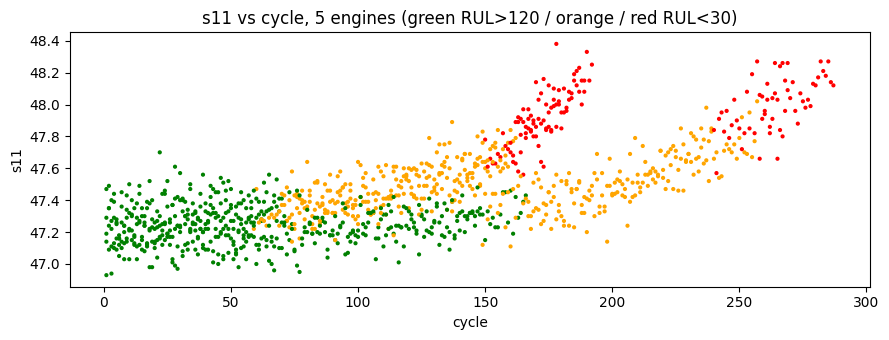

mean z(s11): early life = -0.64 | last 20 cycles = 1.83  (shift 2.5 sigma)


In [3]:
fig, ax = plt.subplots(figsize=(9, 3.5))
for u in tr1.unit.unique()[:5]:
    g = tr1[tr1.unit == u]
    c = np.where(g.rul > HEALTHY_RUL, 'green', np.where(g.rul < 30, 'red', 'orange'))
    ax.scatter(g.cycle, g.s11, c=c, s=4)
ax.set(title='s11 vs cycle, 5 engines (green RUL>120 / orange / red RUL<30)',
       xlabel='cycle', ylabel='s11')
plt.tight_layout(); plt.savefig('../results/figures/03_q2_s11.png', dpi=120); plt.show()
z11 = (tr1.s11 - tr1.s11.mean()) / tr1.s11.std()
print('mean z(s11): early life = %.2f | last 20 cycles = %.2f  (shift %.1f sigma)' %
      (z11[tr1.rul > HEALTHY_RUL].mean(), z11[tr1.rul < 20].mean(),
       z11[tr1.rul < 20].mean() - z11[tr1.rul > HEALTHY_RUL].mean()))

## Q3 — The trajectory in 2D (central figure of the project)

### PCA spectrum: the primary visual justification for k=3
Explained variance across all 14 sensors. PC1 dominates (50%), PC2 drops sharply to 9%, then
PC3-PC14 form a slow noise floor (each ≤5%). k=3 captures 65% cumulative variance — the elbow
before the rolloff. TwoNN below confirms this geometrically (intrinsic d ≈ 3).

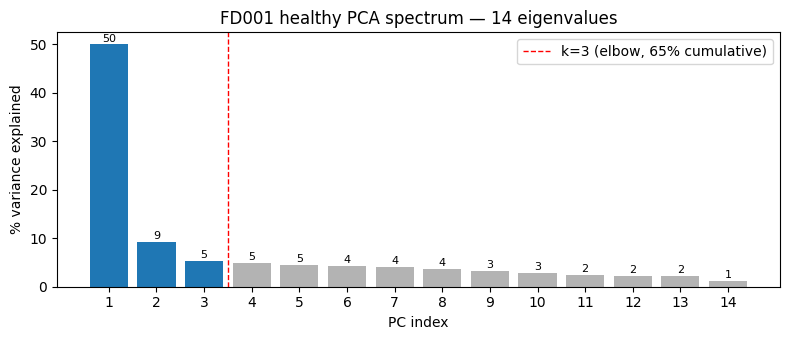

per-PC %:       50.0  9.3  5.3  4.8  4.6  4.2  4.1  3.7  3.2  2.8  2.4  2.2  2.2  1.3
cumulative %:   50.0 59.3 64.6 69.4 74.0 78.2 82.3 85.9 89.1 91.9 94.3 96.6 98.7 100.0


In [4]:
H = tr1[tr1.rul > HEALTHY_RUL]
mu, sd = H[SENSORS].mean(), H[SENSORS].std() + 1e-9
zn = lambda d: (d[SENSORS] - mu) / sd
evr = PCA(len(SENSORS)).fit(zn(H)).explained_variance_ratio_
cum = np.cumsum(evr); k = 3

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(range(1, len(evr) + 1), 100 * evr,
       color=['C0'] * k + ['0.7'] * (len(evr) - k))
ax.axvline(k + 0.5, ls='--', c='r', lw=1,
           label=f'k={k} (elbow, {100 * cum[k - 1]:.0f}% cumulative)')
for i, v in enumerate(evr, 1):
    ax.text(i, 100 * v + 0.6, f'{100 * v:.0f}', ha='center', fontsize=8)
ax.set(xlabel='PC index', ylabel='% variance explained',
       title='FD001 healthy PCA spectrum — 14 eigenvalues')
ax.set_xticks(range(1, len(evr) + 1)); ax.legend()
plt.tight_layout(); plt.savefig('../results/figures/03_q3a_scree.png', dpi=120); plt.show()
print('per-PC %:      ', ' '.join(f'{100 * v:4.1f}' for v in evr))
print('cumulative %:  ', ' '.join(f'{100 * c:4.1f}' for c in cum))

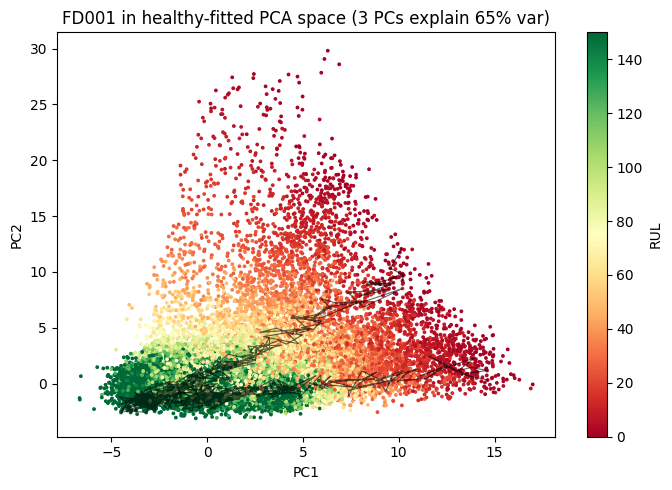

In [5]:
pca = PCA(3).fit(zn(H))
Z = pca.transform(zn(tr1))
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(Z[:, 0], Z[:, 1], c=tr1.rul, cmap='RdYlGn', s=3, vmax=150)
plt.colorbar(sc, label='RUL')
for u in [1, 2]:
    m = (tr1.unit == u).values
    ax.plot(Z[m, 0], Z[m, 1], 'k-', lw=.8, alpha=.6)
ax.set(title='FD001 in healthy-fitted PCA space (3 PCs explain %.0f%% var)'
       % (100 * pca.explained_variance_ratio_.sum()), xlabel='PC1', ylabel='PC2')
plt.tight_layout(); plt.savefig('../results/figures/03_q3_pca.png', dpi=120); plt.show()

## Method 3 — TwoNN (Section 2.4): intrinsic dimension of the healthy manifold
PCA gives an upper bound on dimensionality (linear, ignores curvature). TwoNN uses only local
distance ratios `μ = d₂/d₁` — density-independent, works on curved manifolds. Under the manifold
hypothesis these ratios are Pareto-distributed, so a log-log survival plot has slope `−d`.

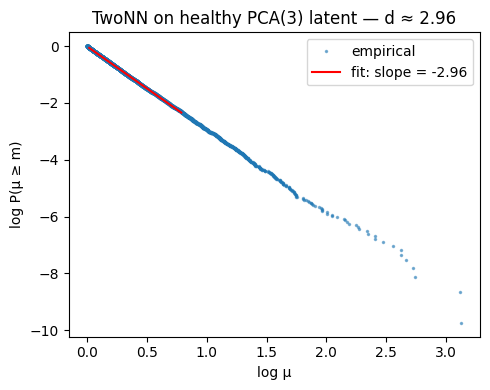

TwoNN intrinsic dimension: 2.96  |  PCA explains 65% in 3 PCs -> healthy manifold is genuinely low-dimensional, not a linear-projection artifact.


In [6]:
from sklearn.neighbors import NearestNeighbors

Zh = pca.transform(zn(H))
dist, _ = NearestNeighbors(n_neighbors=3).fit(Zh).kneighbors(Zh)
ratio = dist[:, 2] / np.clip(dist[:, 1], 1e-12, None)   # d2/d1 (col 0 is self)
ratio = ratio[np.isfinite(ratio) & (ratio > 1.0)]

r_sorted = np.sort(ratio)
surv = 1.0 - (np.arange(len(r_sorted)) + 0.5) / len(r_sorted)   # Hazen positions
x, y = np.log(r_sorted), np.log(surv)
lo, hi = int(0.05 * len(x)), int(0.90 * len(x))                  # drop noisy tails
slope, intercept = np.polyfit(x[lo:hi], y[lo:hi], 1)
d_int = -slope

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(x, y, '.', ms=3, alpha=.5, label='empirical')
ax.plot(x[lo:hi], slope * x[lo:hi] + intercept, 'r-', lw=1.5,
        label=f'fit: slope = -{d_int:.2f}')
ax.set(xlabel='log μ', ylabel='log P(μ ≥ m)',
       title=f'TwoNN on healthy PCA(3) latent — d ≈ {d_int:.2f}')
ax.legend(); plt.tight_layout()
plt.savefig('../results/figures/03_q3b_twonn.png', dpi=120); plt.show()
print(f'TwoNN intrinsic dimension: {d_int:.2f}  |  PCA explains '
      f'{100 * pca.explained_variance_ratio_.sum():.0f}% in 3 PCs '
      f'-> healthy manifold is genuinely low-dimensional, not a linear-projection artifact.')

Clear RUL gradient: degradation is a low-dimensional geometric process — the thesis of the project.

## Q4 — Operating regimes (FD004): the s21 collapse

In [7]:
ra = RegimeAssigner().fit(tr4); t4 = ra.assign(tr4)
nm = Normalizer(by_regime=True).fit(t4[t4.rul > HEALTHY_RUL]); t4n = nm.transform(t4)
raw  = abs(np.corrcoef(tr4.s21, tr4.rul)[0, 1])
norm = abs(np.corrcoef(t4n.s21, t4n.rul)[0, 1])
s11n = abs(np.corrcoef(t4n.s11, t4n.rul)[0, 1])

fd1_s21 = abs(np.corrcoef(tr1.s21, tr1.rul)[0, 1])
print('FD001 |corr(s21, RUL)|: %.2f  (single regime, strong signal)' % fd1_s21)
print('FD004 |corr(s21, RUL)|: raw global = %.2f -> per-regime normalized = %.2f' % (raw, norm))
print('=> s21 collapse: FD001 %.2f -> FD004 regime-normalized %.2f' % (fd1_s21, norm))
print('FD004 |corr(s11, RUL)| after regime norm = %.2f (survives)' % s11n)

FD001 |corr(s21, RUL)|: 0.64  (single regime, strong signal)
FD004 |corr(s21, RUL)|: raw global = 0.00 -> per-regime normalized = 0.04
=> s21 collapse: FD001 0.64 -> FD004 regime-normalized 0.04
FD004 |corr(s11, RUL)| after regime norm = 0.69 (survives)


Sensors that look informative under regime mixing can be useless once regimes are removed
(s21), while s11 survives. **Preprocessing changes the feature story** — this is the motivation for ablation A1.

## Fault-mode preview: per-unit late-life directions (FD001 vs FD003)

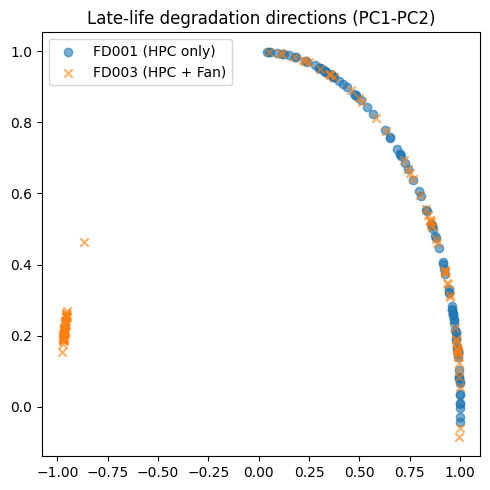

FD003 forms two lobes; FD001 one — quantified in notebook 06.


In [8]:
def unit_dirs(df):
    out = []
    for u, g in df[df.rul < 15].groupby('unit'):
        if len(g) < 5: continue
        v = pca.transform(zn(g)).mean(0) - pca.transform(zn(H)).mean(0)
        out.append(v / np.linalg.norm(v))
    return np.array(out)
D1, D3 = unit_dirs(tr1), unit_dirs(tr3)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(D1[:, 0], D1[:, 1], label='FD001 (HPC only)', alpha=.6)
ax.scatter(D3[:, 0], D3[:, 1], label='FD003 (HPC + Fan)', alpha=.6, marker='x')
ax.set(title='Late-life degradation directions (PC1-PC2)'); ax.legend()
plt.tight_layout(); plt.savefig('../results/figures/03_dirs.png', dpi=120); plt.show()
print('FD003 forms two lobes; FD001 one — quantified in notebook 06.')